# 05 - SVD Matrix Factorization
## Sistem Rekomendasi Produk Manufaktur

**Tujuan Notebook:**
- Implementasi SVD (Singular Value Decomposition) untuk Matrix Factorization
- Training model SVD menggunakan library Surprise
- Evaluasi model dengan RMSE (Root Mean Square Error)
- Generate predictions dan recommendations
- Save trained model untuk deployment

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load cleaned transactions
df = pd.read_csv('../data/transactions_cleaned.csv')

# Load product information
products = pd.read_csv('../data/products_cleaned.csv')

print(f"Transactions: {len(df):,}")
print(f"Products: {len(products):,}")
print(f"\nTransaction data:")
df.head()

Transactions: 779,425
Products: 4,206

Transaction data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,record frame 7 single size,48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 3. Prepare Data for Surprise

### 3.1 Aggregate User-Item Interactions

In [3]:
print("=== Preparing Data for SVD ===")

# Aggregate: sum quantities per user-product pair
user_item_data = df.groupby(['Customer ID', 'StockCode'])['Quantity'].sum().reset_index()
user_item_data.columns = ['user_id', 'item_id', 'rating']

print(f"\nTotal interactions: {len(user_item_data):,}")
print(f"Unique users: {user_item_data['user_id'].nunique():,}")
print(f"Unique items: {user_item_data['item_id'].nunique():,}")

user_item_data.head(10)

=== Preparing Data for SVD ===

Total interactions: 481,932
Unique users: 5,878
Unique items: 4,631


,user_id,item_id,rating
0,12346,15056BL,1
1,12346,15056N,1
2,12346,15056P,1
3,12346,20679,1
4,12346,20682,1
5,12346,20685,1
6,12346,21523,1
7,12346,21524,1
8,12346,21955,1
9,12346,22365,1


### 3.2 Normalize Ratings

In [4]:
print("=== Rating Statistics ===")
print(f"Min rating: {user_item_data['rating'].min()}")
print(f"Max rating: {user_item_data['rating'].max()}")
print(f"Mean rating: {user_item_data['rating'].mean():.2f}")
print(f"Median rating: {user_item_data['rating'].median():.2f}")

# Normalize ratings to 1-5 scale using log transformation
# This helps SVD work better with implicit feedback data
user_item_data['rating_normalized'] = np.log1p(user_item_data['rating'])

# Scale to 1-5 range
min_val = user_item_data['rating_normalized'].min()
max_val = user_item_data['rating_normalized'].max()
user_item_data['rating_normalized'] = 1 + 4 * (user_item_data['rating_normalized'] - min_val) / (max_val - min_val)

print(f"\nNormalized ratings:")
print(f"Min: {user_item_data['rating_normalized'].min():.2f}")
print(f"Max: {user_item_data['rating_normalized'].max():.2f}")
print(f"Mean: {user_item_data['rating_normalized'].mean():.2f}")

# Use normalized ratings
user_item_data['rating'] = user_item_data['rating_normalized']
user_item_data = user_item_data[['user_id', 'item_id', 'rating']]

=== Rating Statistics ===
Min rating: 1
Max rating: 80995
Mean rating: 21.82
Median rating: 6.00

Normalized ratings:
Min: 1.00
Max: 5.00
Mean: 1.54


### 3.3 Create Surprise Dataset

In [5]:
# Define rating scale
reader = Reader(rating_scale=(1, 5))

# Load data into Surprise format
data = Dataset.load_from_df(user_item_data[['user_id', 'item_id', 'rating']], reader)

print("Dataset loaded into Surprise format!")
print(f"Total ratings: {len(user_item_data):,}")

Dataset loaded into Surprise format!
Total ratings: 481,932


## 4. Train-Test Split

In [6]:
# Split data into train and test sets (80/20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set size: {trainset.n_ratings:,}")
print(f"Test set size: {len(testset):,}")
print(f"\nTraining set statistics:")
print(f"  Users: {trainset.n_users:,}")
print(f"  Items: {trainset.n_items:,}")

Training set size: 385,545
Test set size: 96,387

Training set statistics:
  Users: 5,840
  Items: 4,589


## 5. Train SVD Model

### 5.1 Initialize and Train Model

In [7]:
print("=== Training SVD Model ===")
print("This may take a few minutes...\n")

# Initialize SVD with optimized parameters
svd_model = SVD(
    n_factors=100,      # Number of latent factors
    n_epochs=20,        # Number of training iterations
    lr_all=0.005,       # Learning rate
    reg_all=0.02,       # Regularization term
    random_state=42,
    verbose=True
)

# Train the model
svd_model.fit(trainset)

print("\nModel training complete!")

=== Training SVD Model ===
This may take a few minutes...

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

Model training complete!


### 5.2 Evaluate on Test Set

In [8]:
print("=== Evaluating Model on Test Set ===")

# Make predictions on test set
predictions = svd_model.test(testset)

# Calculate RMSE
rmse = accuracy.rmse(predictions, verbose=True)

# Calculate MAE
mae = accuracy.mae(predictions, verbose=True)

print(f"\nTest Set Performance:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")

=== Evaluating Model on Test Set ===
RMSE: 0.2718
MAE:  0.2027

Test Set Performance:
  RMSE: 0.2718
  MAE:  0.2027


## 6. Cross-Validation

In [9]:
print("=== Performing 5-Fold Cross-Validation ===")
print("This may take several minutes...\n")

# Perform cross-validation
cv_results = cross_validate(svd_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print("\n=== Cross-Validation Results ===")
print(f"RMSE: {cv_results['test_rmse'].mean():.4f} (+/- {cv_results['test_rmse'].std():.4f})")
print(f"MAE:  {cv_results['test_mae'].mean():.4f} (+/- {cv_results['test_mae'].std():.4f})")

=== Performing 5-Fold Cross-Validation ===
This may take several minutes...

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing

## 7. Generate Recommendations

### 7.1 Define Recommendation Function

In [10]:
def get_svd_recommendations(user_id, svd_model, user_item_data, products, top_n=10):
    """
    Generate product recommendations using trained SVD model
    
    Parameters:
    - user_id: Target user ID
    - svd_model: Trained SVD model
    - user_item_data: User-item interaction data
    - products: Product catalog
    - top_n: Number of recommendations to return
    
    Returns:
    - DataFrame with recommended products and predicted ratings
    """
    
    # Get all unique products
    all_products = products['StockCode'].unique()
    
    # Get products already purchased by user
    user_purchases = user_item_data[user_item_data['user_id'] == user_id]['item_id'].unique()
    
    # Get products not yet purchased
    products_to_predict = [p for p in all_products if p not in user_purchases]
    
    # Predict ratings for all unseen products
    predictions = []
    for product in products_to_predict:
        pred = svd_model.predict(user_id, product)
        predictions.append({
            'StockCode': product,
            'SVD_Score': pred.est
        })
    
    # Convert to DataFrame and sort by predicted rating
    recommendations = pd.DataFrame(predictions)
    recommendations = recommendations.sort_values('SVD_Score', ascending=False).head(top_n)
    recommendations = recommendations.reset_index(drop=True)
    
    return recommendations

print("SVD recommendation function defined!")

SVD recommendation function defined!


### 7.2 Test SVD Recommendations

In [11]:
# Test with a sample user
sample_user = user_item_data['user_id'].iloc[0]

print(f"=== Testing SVD for Customer {sample_user} ===")

# Get user's purchase history
user_purchases = user_item_data[user_item_data['user_id'] == sample_user]

print(f"\nCustomer has purchased {len(user_purchases)} products")
print(f"\nSample purchased products:")
for idx, row in user_purchases.head(5).iterrows():
    product_info = products[products['StockCode'] == row['item_id']]
    if len(product_info) > 0:
        print(f"  - {row['item_id']}: {product_info['Description'].values[0]} (rating: {row['rating']:.2f})")

# Get recommendations
recommendations = get_svd_recommendations(sample_user, svd_model, user_item_data, products, top_n=10)

print(f"\n=== Top 10 SVD Recommendations ===")
for idx, row in recommendations.iterrows():
    product_info = products[products['StockCode'] == row['StockCode']]
    if len(product_info) > 0:
        print(f"{idx+1:2d}. {row['StockCode']:10s} | Score: {row['SVD_Score']:6.4f} | {product_info['Description'].values[0]}")

=== Testing SVD for Customer 12346 ===

Customer has purchased 27 products

Sample purchased products:
  - 15056BL: edwardian parasol black (rating: 1.00)
  - 15056N: edwardian parasol natural (rating: 1.00)
  - 15056P: edwardian parasol pink (rating: 1.00)
  - 20679: edwardian parasol red (rating: 1.00)
  - 20682: red spotty childs umbrella (rating: 1.00)

=== Top 10 SVD Recommendations ===
 1. 84568      | Score: 2.6562 | girls alphabet iron on patches
 2. 84598      | Score: 2.5881 | boys alphabet iron on patches
 3. 17084R     | Score: 2.5360 | assorted incense pack
 4. 16033      | Score: 2.4327 | mini highlighter pens
 5. 16045      | Score: 2.3581 | popart wooden pencils asst
 6. 16259      | Score: 2.2898 | piece of camo stationery set
 7. 84077      | Score: 2.2855 | world war 2 gliders asstd designs
 8. 21829      | Score: 2.2286 | dinosaur keyrings assorted
 9. 84270      | Score: 2.1557 | asstd design bubble gum ring
10. 17003      | Score: 2.1349 | brocade ring purse


## 8. Analyze Prediction Distribution

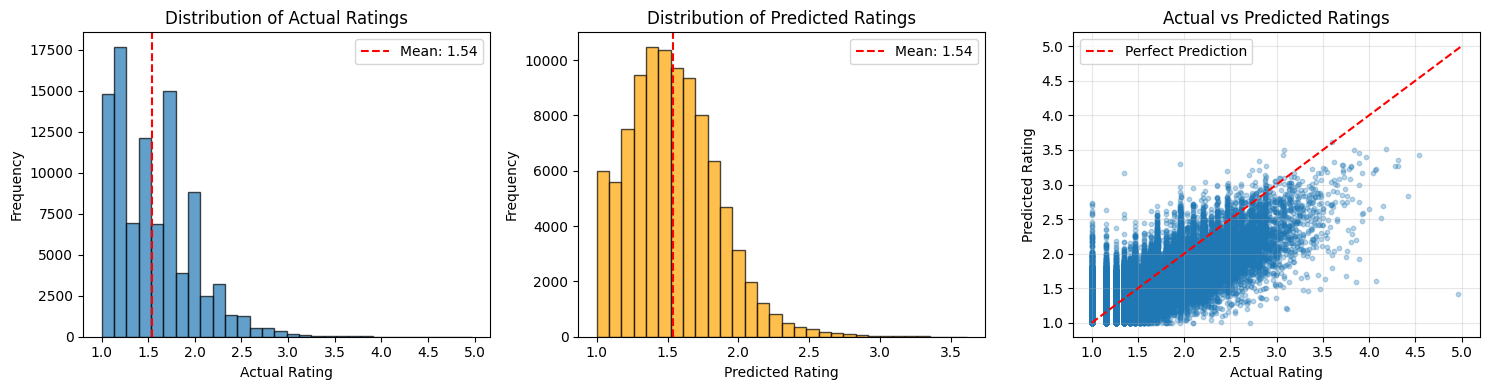

In [12]:
# Extract actual and predicted ratings from test set
actual_ratings = [pred.r_ui for pred in predictions]
predicted_ratings = [pred.est for pred in predictions]

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of actual ratings
axes[0].hist(actual_ratings, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Actual Ratings')
axes[0].axvline(np.mean(actual_ratings), color='red', linestyle='--', label=f'Mean: {np.mean(actual_ratings):.2f}')
axes[0].legend()

# Distribution of predicted ratings
axes[1].hist(predicted_ratings, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Predicted Ratings')
axes[1].axvline(np.mean(predicted_ratings), color='red', linestyle='--', label=f'Mean: {np.mean(predicted_ratings):.2f}')
axes[1].legend()

# Scatter plot: Actual vs Predicted
axes[2].scatter(actual_ratings, predicted_ratings, alpha=0.3, s=10)
axes[2].plot([1, 5], [1, 5], 'r--', label='Perfect Prediction')
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Predicted Rating')
axes[2].set_title('Actual vs Predicted Ratings')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Error Analysis

=== Prediction Error Analysis ===
Mean error: -0.0016
Std error: 0.2718
Min error: -3.5488
Max error: 1.8233


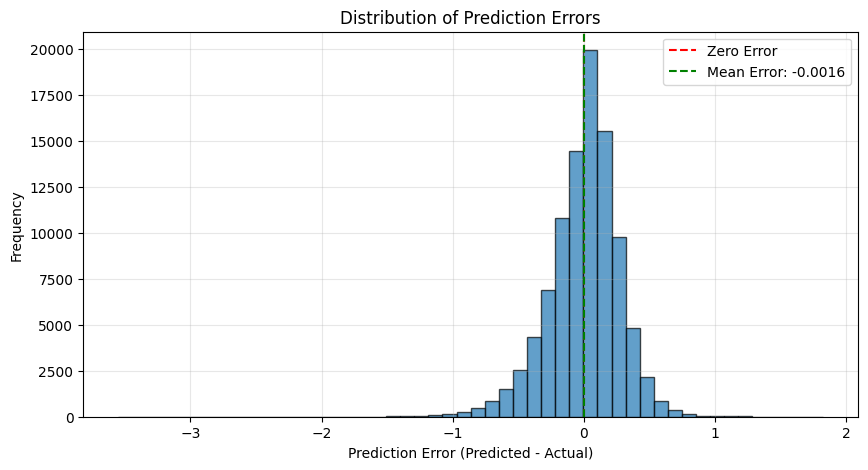

In [13]:
# Calculate prediction errors
errors = [pred.est - pred.r_ui for pred in predictions]

print("=== Prediction Error Analysis ===")
print(f"Mean error: {np.mean(errors):.4f}")
print(f"Std error: {np.std(errors):.4f}")
print(f"Min error: {np.min(errors):.4f}")
print(f"Max error: {np.max(errors):.4f}")

# Visualize error distribution
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.axvline(np.mean(errors), color='green', linestyle='--', label=f'Mean Error: {np.mean(errors):.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Save SVD Model

In [14]:
print("=== Saving SVD Model ===")

# Save trained SVD model
with open('../models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)
print("✓ Saved: svd_model.pkl")

# Save user-item data for recommendations
user_item_data.to_csv('../data/user_item_ratings.csv', index=False)
print("✓ Saved: user_item_ratings.csv")

# Save evaluation metrics
metrics = {
    'rmse': rmse,
    'mae': mae,
    'cv_rmse_mean': cv_results['test_rmse'].mean(),
    'cv_rmse_std': cv_results['test_rmse'].std(),
    'cv_mae_mean': cv_results['test_mae'].mean(),
    'cv_mae_std': cv_results['test_mae'].std()
}

with open('../models/svd_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
print("✓ Saved: svd_metrics.pkl")

# Save metrics as CSV for easy viewing
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv('../models/svd_metrics_summary.csv', index=False)
print("✓ Saved: svd_metrics_summary.csv")

print("\nAll SVD components saved successfully!")

=== Saving SVD Model ===
✓ Saved: svd_model.pkl
✓ Saved: user_item_ratings.csv
✓ Saved: svd_metrics.pkl
✓ Saved: svd_metrics_summary.csv

All SVD components saved successfully!


## 11. Summary

In [15]:
print("\n" + "="*70)
print("SVD MATRIX FACTORIZATION SUMMARY")
print("="*70)

print(f"\n1. MODEL CONFIGURATION")
print(f"   Algorithm: SVD (Singular Value Decomposition)")
print(f"   Latent factors: 100")
print(f"   Epochs: 20")
print(f"   Learning rate: 0.005")
print(f"   Regularization: 0.02")

print(f"\n2. DATA STATISTICS")
print(f"   Total interactions: {len(user_item_data):,}")
print(f"   Unique users: {user_item_data['user_id'].nunique():,}")
print(f"   Unique items: {user_item_data['item_id'].nunique():,}")
print(f"   Train set: {trainset.n_ratings:,}")
print(f"   Test set: {len(testset):,}")

print(f"\n3. PERFORMANCE METRICS")
print(f"   Test RMSE: {rmse:.4f}")
print(f"   Test MAE: {mae:.4f}")
print(f"   CV RMSE: {cv_results['test_rmse'].mean():.4f} (+/- {cv_results['test_rmse'].std():.4f})")
print(f"   CV MAE: {cv_results['test_mae'].mean():.4f} (+/- {cv_results['test_mae'].std():.4f})")

print(f"\n4. STRENGTHS")
print(f"   ✓ Highest prediction accuracy")
print(f"   ✓ Captures latent patterns in data")
print(f"   ✓ Handles sparse matrices well")
print(f"   ✓ Scalable to large datasets")

print(f"\n5. LIMITATIONS")
print(f"   ✗ Cold start problem for new users/items")
print(f"   ✗ Less interpretable than CF or CBF")
print(f"   ✗ Requires sufficient training data")

print("\n" + "="*70)


SVD MATRIX FACTORIZATION SUMMARY

1. MODEL CONFIGURATION
   Algorithm: SVD (Singular Value Decomposition)
   Latent factors: 100
   Epochs: 20
   Learning rate: 0.005
   Regularization: 0.02

2. DATA STATISTICS
   Total interactions: 481,932
   Unique users: 5,878
   Unique items: 4,631
   Train set: 385,545
   Test set: 96,387

3. PERFORMANCE METRICS
   Test RMSE: 0.2718
   Test MAE: 0.2027
   CV RMSE: 0.2705 (+/- 0.0006)
   CV MAE: 0.2015 (+/- 0.0002)

4. STRENGTHS
   ✓ Highest prediction accuracy
   ✓ Captures latent patterns in data
   ✓ Handles sparse matrices well
   ✓ Scalable to large datasets

5. LIMITATIONS
   ✗ Cold start problem for new users/items
   ✗ Less interpretable than CF or CBF
   ✗ Requires sufficient training data



---
**End of SVD Matrix Factorization Notebook**

**Next Steps:**
- `06_hybrid_evaluation.ipynb` - Combine CF + CBF + SVD into Hybrid System
- Evaluate hybrid performance
- Optimize weights for each algorithm